# HW13: Классификация текста с BERT

Домашнее задание к семинару 13

**Тема:** токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

---

## 1. Импорты, seed и среда
Импортируем необходимые библиотеки, фиксируем seed, определяем устройство (cuda/cpu).

In [1]:
# Импорты, seed и определение устройства
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Для загрузки датасетов и моделей
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

d:\VSCode\MLenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Используемое устройство: cpu


## 2. Данные и первичный анализ

- Загрузим датасет (по умолчанию `emotion`).
- Посмотрим размеры частей, примеры текстов и меток.
- Кратко опишем задачу классификации.

In [2]:
# Загрузка датасета (по умолчанию 'emotion')
dataset = load_dataset('emotion')

# Размеры частей
def print_split_sizes(ds):
    for split in ds:
        print(f"{split}: {len(ds[split])} samples")
print_split_sizes(dataset)

# Примеры текстов и меток
for split in ['train', 'validation', 'test']:
    print(f"\nПримеры из {split}:")
    for i in range(3):
        print(f"Text: {dataset[split][i]['text']}")
        print(f"Label: {dataset[split][i]['label']}")
        print('-' * 40)

# Краткое описание задачи
print("\nЗадача: Классификация эмоций по тексту на английском языке. Классы: ", dataset['train'].features['label'].names)

train: 16000 samples
validation: 2000 samples
test: 2000 samples

Примеры из train:
Text: i didnt feel humiliated
Label: 0
----------------------------------------
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: 0
----------------------------------------
Text: im grabbing a minute to post i feel greedy wrong
Label: 3
----------------------------------------

Примеры из validation:
Text: im feeling quite sad and sorry for myself but ill snap out of it soon
Label: 0
----------------------------------------
Text: i feel like i am still looking at a blank canvas blank pieces of paper
Label: 0
----------------------------------------
Text: i feel like a faithful servant
Label: 2
----------------------------------------

Примеры из test:
Text: im feeling rather rotten so im not very ambitious right now
Label: 0
----------------------------------------
Text: im updating my blog because i feel shitty
Label: 0
-----------

## 3. Токенизация

- Покажем токенизацию для 3-5 текстов:
  - токены
  - input_ids
  - attention_mask
  - special tokens
  - padding/truncation

In [3]:
# Выбор модели и токенизатора
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Примеры для токенизации
examples = [dataset['train'][i]['text'] for i in range(5)]

for text in examples:
    print(f"\nТекст: {text}")
    encoded = tokenizer(text, padding='max_length', truncation=True, max_length=16)
    print("Tokens:", tokenizer.convert_ids_to_tokens(encoded['input_ids']))
    print("input_ids:", encoded['input_ids'])
    print("attention_mask:", encoded['attention_mask'])
    print("Special tokens mask:", tokenizer.get_special_tokens_mask(encoded['input_ids'], already_has_special_tokens=True))


Текст: i didnt feel humiliated
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Special tokens mask: [1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Special tokens mask: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

Текст: im grabbing a minute to post i feel greedy wrong
Tokens: ['[CLS]', 'im', 'grabbing', 'a', 'minu

## 4. Инференс готовой модели

- Запустим инференс pretrained BERT-подобной модели на 3-5 текстах.
- Покажем результаты и кратко прокомментируем.

In [4]:
# Инференс готовой модели на примерах
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(dataset['train'].features['label'].names)).to(device)
model.eval()

pipe = pipeline('text-classification', model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

for text in examples:
    result = pipe(text)[0]
    print(f"\nТекст: {text}")
    print(f"Предсказание: {result['label']}, score: {result['score']:.3f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu



Текст: i didnt feel humiliated
Предсказание: LABEL_3, score: 0.186

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Предсказание: LABEL_3, score: 0.184

Текст: im grabbing a minute to post i feel greedy wrong
Предсказание: LABEL_3, score: 0.187

Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Предсказание: LABEL_3, score: 0.181

Текст: i am feeling grouchy
Предсказание: LABEL_3, score: 0.185


## 5. Fine-tuning модели для классификации текста

- Подготовим датасет и токенизацию для обучения.
- Обучим модель на train, выберем лучший вариант по validation.
- Оценим на test.

In [5]:
# Токенизация датасета для обучения
from transformers import DataCollatorWithPadding

def tokenize_function(example):
    return tokenizer(example['text'], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Подготовка модели для обучения
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(dataset['train'].features['label'].names)).to(device)

# TrainingArguments и Trainer
training_args = TrainingArguments(
    output_dir='/results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    seed=SEED,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {'accuracy': acc, 'f1_macro': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Karl\AppData\Local\Temp\ipykernel_18772\3639917513.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
d:\VSCode\MLenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.715400
1000,0.255500
1500,0.152400
2000,0.143200


d:\VSCode\MLenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=2000, training_loss=0.31662750244140625, metrics={'train_runtime': 1141.0879, 'train_samples_per_second': 28.043, 'train_steps_per_second': 1.753, 'total_flos': 389287358125632.0, 'train_loss': 0.31662750244140625, 'epoch': 2.0})

## 6. Оценка качества и анализ ошибок

- Accuracy, f1_macro на test
- Матрица ошибок
- Примеры предсказаний
- Краткий анализ ошибок

d:\VSCode\MLenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.9245
Test f1_macro: 0.8760


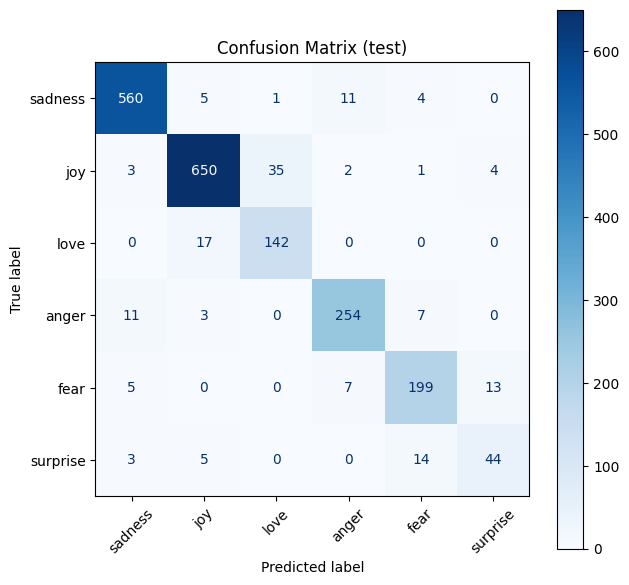


Ошибки модели (несовпадения):
                                                  text true_label pred_label  \
10                  i don t feel particularly agitated       fear      anger   
72   i am right handed however i play billiards lef...   surprise       fear   
86   i feel like i am in paradise kissing those swe...        joy       love   
93   i was feeling weird the other day and it went ...       fear   surprise   
94           when a friend dropped a frog down my neck      anger       fear   
98     i feel my heart is tortured by what i have done      anger       fear   
103  i feel agitated with myself that i did not for...       fear      anger   
108  i looked at mabel this morning i named my left...       fear   surprise   
131  im feeling generous today heres one more you m...       love        joy   
150              im feeling rather angsty and listless    sadness       love   

     confidence  
10     4.044601  
72     3.365684  
86     3.470809  
93     3.030646 

In [6]:
# Оценка на test-части
preds = trainer.predict(tokenized_datasets['test'])
y_true = preds.label_ids
y_pred = preds.predictions.argmax(axis=-1)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
print(f"Test accuracy: {acc:.4f}")
print(f"Test f1_macro: {f1:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
labels = dataset['train'].features['label'].names
fig, ax = plt.subplots(figsize=(7,7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (test)')
plt.savefig('artifacts/confusion_matrix.png')
plt.show()

# Сохраним sample_predictions.csv
sample_df = pd.DataFrame({
    'text': [dataset['test'][i]['text'] for i in range(len(y_true))],
    'true_label': [labels[i] for i in y_true],
    'pred_label': [labels[i] for i in y_pred],
    'confidence': preds.predictions.max(axis=1)
})
sample_df.head(10)
sample_df.to_csv('artifacts/sample_predictions.csv', index=False)

# Примеры ошибок
errors = sample_df[sample_df['true_label'] != sample_df['pred_label']]
print("\nОшибки модели (несовпадения):")
print(errors.head(10))